In [1]:
import os
os.environ['KAGGLE_USERNAME'] = "key"
os.environ['KAGGLE_KEY'] = "token"

!kaggle datasets download -d vipoooool/new-plant-diseases-dataset
!unzip -q new-plant-diseases-dataset.zip -d dataset

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [01:41<00:00, 28.7MB/s]



In [2]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = '/content/dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/train'
valid_dir = '/content/dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2
)

valid_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print(f"Số class: {train_generator.num_classes}")
print(f"Số ảnh train: {train_generator.samples}")
print(f"Số ảnh valid: {valid_generator.samples}")

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.
Số class: 38
Số ảnh train: 70295
Số ảnh valid: 17572


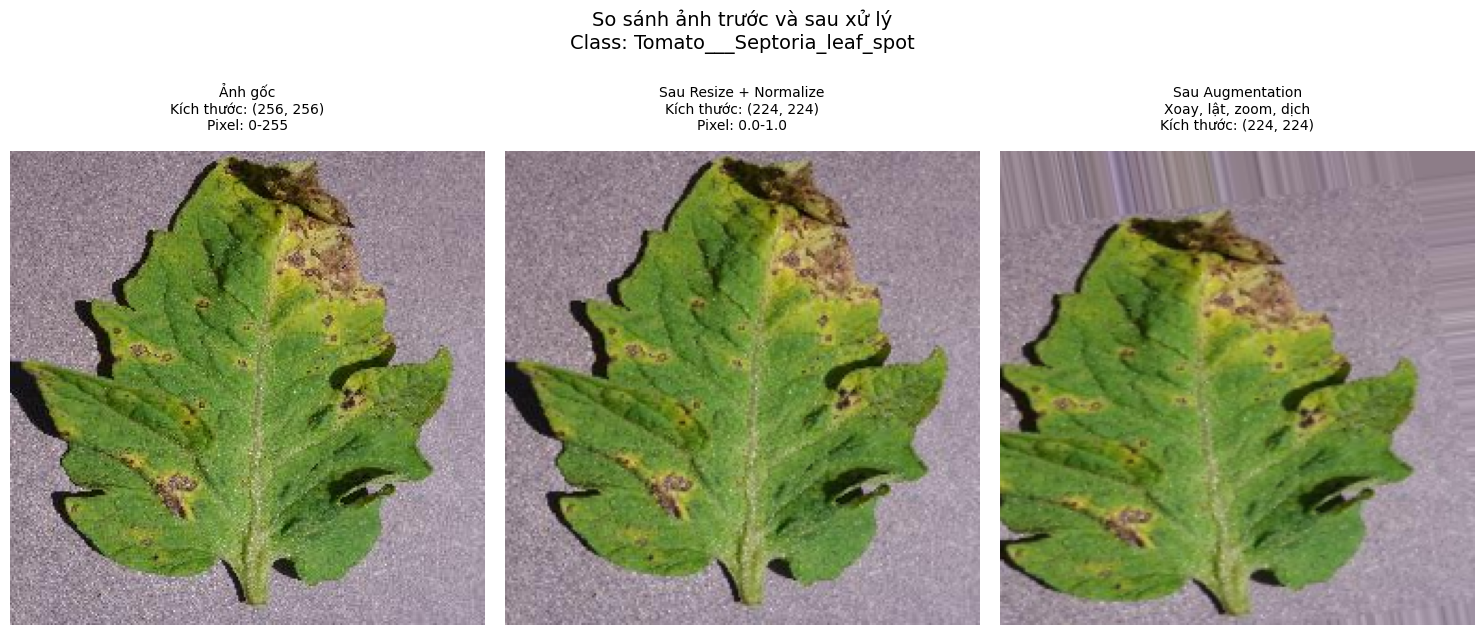

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import random

sample_class = random.choice(os.listdir(train_dir))
sample_img_name = random.choice(os.listdir(os.path.join(train_dir, sample_class)))
sample_img_path = os.path.join(train_dir, sample_class, sample_img_name)

original_img = Image.open(sample_img_path).convert('RGB')
original_size = original_img.size

processed_img = original_img.resize((224, 224))
processed_array = np.array(processed_img) / 255.0

aug_datagen = ImageDataGenerator(
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2
)
img_array = np.array(processed_img)
img_array = img_array.reshape((1,) + img_array.shape)
aug_img = next(aug_datagen.flow(img_array))[0].astype('uint8')

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

axes[0].imshow(original_img)
axes[0].set_title('Ảnh gốc\nKích thước: {}\nPixel: 0-255'.format(original_size), fontsize=10, pad=15)
axes[0].axis('off')

axes[1].imshow(processed_array)
axes[1].set_title('Sau Resize + Normalize\nKích thước: (224, 224)\nPixel: 0.0-1.0', fontsize=10, pad=15)
axes[1].axis('off')

axes[2].imshow(aug_img)
axes[2].set_title('Sau Augmentation\nXoay, lật, zoom, dịch\nKích thước: (224, 224)', fontsize=10, pad=15)
axes[2].axis('off')

plt.suptitle(f'So sánh ảnh trước và sau xử lý\nClass: {sample_class}', fontsize=14, y=1.05)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('before_after_preprocessing.png')
plt.show()